**Instituto Tecnológico de Aeronáutica – ITA**

**Deep Learning – CM-204**

**Professor:**

Marcos Ricardo Omena de Albuquerque Maximo

# Laboratório 1 – Descida de Gradiente e Introdução ao Pytorch


Observações:
- Para alterar este notebook, salve uma cópia no seu Drive em ``File > Save a copy in Drive``.
- **Não** exclua células, pois isto pode gerar problemas para o autocorretor.

# 1. Introdução

Nesse laboratório, seu objetivo é o algoritmo de Descida de Gradiente, tanto usando diretamente operações da biblioteca NumPy quanto com a PyTorch. Os métodos serão testados em um problema em que se usa regressão linear para obter parâmetros físicos relativos ao movimento de uma bola. No caso, trata-se apenas de um problema brinquedo, dado que esse problema especificamente tem solução analítica, logo o Método dos Mínimos Quadrados (MMQ) o resolve mais facilmente.

# 2. Descrição do Problema

O problema ser resolvido é a otimização de funções matemáticas (em que é possível obter amostras da função e de sua derivada) usando os métodos descritos, assim sua implementação não deve ser específica para o caso de teste. A descrição do algoritmo que será implementado pode ser vista nos slides do curso.

No caso de teste, o problema específico a ser resolvido é a determinação do coeficiente de desaceleração de uma bola em movimento num campo de futebol de robôs. A bola em movimento perde energia devido a um fenômeno conhecido como *rolling friction*. Conforme explicado em aula, pode-se determinar o coeficiente de desaceleração através do seguinte algoritmo:

1. Usar câmera e visão computacional para obter posições (x,y) da bola em cada instante.
2. Calcular velocidades em x e y usando diferenças finitas centradas (exceto no primeiro e último elementos, em que deve-se usar derivadas *forward* e *backward*, respectivamente):

    $$v_x [k]=(x[k+1]-x[k-1])/(t[k+1]-t[k-1])$$
    $$v_y [k]=(y[k+1]-y[k-1])/(t[k+1]-t[k-1])$$

3. Calcular $v[k]= \sqrt{v_x^2[k] + v_y^2[k]}$.
4. Obter $v_0$ e $f$ através de uma otimização com função de custo:

    $$J([v_0,f])= \sum_{k=1}^n (v_0 + ft[k]-v[k])^2$$
    
Desse modo, tem-se os seguintes parâmetros a serem otimizados:

$\theta_0 = v_0$ e $\theta_1 = f \Rightarrow \theta =[v_0  \: f]^T$

# 3. Código Base

Juntamente com o código base, foi entregue o arquivo data.txt, que contém dados reais do movimento de uma bola no campo de futebol de robôs do Very Small Size (VSS). Esses dados foram obtidos pelo aluno Thiago Filipe de Medeiros da COMP-19 durante uma competição. Para isso, usou-se o *setup* do VSS, incluindo os algoritmos de visão computacional da ITAndroids.

O código base entregue já carrega esses dados automaticamente e os pré-processa de acordo com o procedimento explicado na seção anterior. Além disso, resolve a otimização com uso do MMQ a fim de fornecer valores esperados para $v_0$ e $f$. O código base também já executa os algoritmos que você vai implementar e apresenta gráficos para que você possa verificar sua implementação.

# 4. Tarefas

Você deve implementar o algoritmo de Descida de Gradient tanto em NumPy quanto em PyTorch. Para isso, implemente as seguintes funções:

* `gradient_descent_numpy()`
* `gradient_descent_pytorch()`
    
As implementações desses algoritmos de otimização devem ser as mais genéricas possível e não usar informações específicas do problema de fit da dinâmica da bola. Perceba que as condições de parada de todos os algoritmos envolvem um limiar para o custo (i.e. o algoritmo pára quando $J(\theta)<\epsilon$) e um número máximo de iterações.

Comece rodando a célula abaixo para fazer o download dos dados.

In [ ]:
import zipfile
import os

# Download data (MUST RUN)
!gdown --id 1vhMWMVA4hzLBz2xBQkKGB1RCIoHUxIWv

with zipfile.ZipFile("cm204_lab1_data.zip","r") as zip_ref:
  zip_ref.extractall() # extracts in current directory

# make results folder to save images
if not os.path.exists('results'):
  os.makedirs('results')

os.remove("cm204_lab1_data.zip")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1vhMWMVA4hzLBz2xBQkKGB1RCIoHUxIWv
To: /content/cm204_lab1_data.zip
100% 1.84k/1.84k [00:00<00:00, 4.32MB/s]


A célula abaixo contém funções auxiliares já implementadas para os alunos, sendo elas:
- `cost_function()`: função custo a ser otimizada;
- `plot_optimization()`: plota o histórico da otimização.

In [ ]:
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt

def load_data() -> Tuple[np.array, np.array, np.array]:
    """
    Loads and pre-processes the data from the file 'data.txt'.

    :return: arrays with time and ball's velocity.
    :rtype: tuple of numpy.array.
    """
    data = np.genfromtxt('data.txt')
    t = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    t -= t[0]
    m = len(t)
    vx = np.zeros(m)
    vy = np.zeros(m)
    vx[0] = (x[1] - x[0]) / (t[1] - t[0])
    vy[0] = (y[1] - y[0]) / (t[1] - t[0])
    for k in range(1, m - 1):
        vx[k] = (x[k + 1] - x[k - 1]) / (t[k + 1] - t[k - 1])
        vy[k] = (y[k + 1] - y[k - 1]) / (t[k + 1] - t[k - 1])
    vx[-1] = (x[-1] - x[-2]) / (t[-1] - t[-2])
    vy[-1] = (y[-1] - y[-2]) / (t[-1] - t[-2])
    v = np.sqrt(vx ** 2 + vy ** 2)
    return t, v

t, v = load_data() # Making sure the data has been loaded at least once before needed

def cost_function(theta: np.array) -> float:
    """
    Samples the linear regression cost function.

    :param theta: parameter point.
    :type theta: numpy.array.
    :return: cost value at theta.
    :rtype: float.
    """
    m = len(t)
    return sum((theta[0] + theta[1] * t - v) ** 2) / (2.0 * m)

def plot_optimization(history: list) -> plt.Line2D:
    """
    Plots the optimization history.

    :param history: points visited by the optimization algorithm.
    :type history: list of numpy.array.
    """
    t0 = np.arange(-0.5, 0.5, 0.01)
    t1 = np.arange(-0.5, 0.5, 0.01)
    z = np.zeros((len(t0), len(t1)))
    for i in range(len(t0)):
        for j in range(len(t1)):
            z[i, j] = cost_function(np.array([t0[i], t1[j]]))
    plt.contourf(t0, t1, z.transpose())
    hx = []
    hy = []
    for h in history:
        hx.append(h[0])
        hy.append(h[1])
    handle, = plt.plot(hx, hy, '.-', markersize=5)
    plt.xlabel('v_0 (m/s)')
    plt.ylabel('f (m/s^2)')
    plt.plot(hx[0], hy[0], '*y')
    plt.plot(hx[-1], hy[-1], 'xr')
    return handle

# Defines the file format used for figures
fig_format = 'png'
# fig_format = 'svg'
# fig_format = 'eps'
# Recommended figure formats: .eps for Latex/Linux, .svg for MS Office, and .png for easy visualization in Windows.
# The quality of .eps and .svg is far superior since these are vector graphics formats.

## 4.1 Breve Tutorial de NumPy

A NumPy é uma biblioteca de Álgebra Linear para o Python. A seguir, apresenta-se alguns recursos da NumPy. Caso tenha dificuldade em entender alguma operação, consulte a documentação da NumPy em: https://numpy.org/doc/

Note que esta seção não gera nenhum resultado para a correção, mas recomenda-se que o aluno analise e rode cada célula para se familiarizar com a biblioteca.

Importando a biblioteca:

In [ ]:
import numpy as np

# Verifying if the import was successful
x = np.array([1, 2, 3])
print(x)

[1 2 3]


Definição de vetores e matrizes em NumPy:

In [ ]:
x = np.array([1, 2, 3]) # Defines a integer array with 3 elements
print('x:', x)
y = np.array([1., 2., 3.]) # Defines a float array with 3 elements
print('y:', y)
y = np.array([1, 2, 3], dtype=np.float32) # We can also specify the type of the array
z = np.arange(2, 6, 2) # Defines an array with values from 2 to 6 with a step of 2 (excluding the endpoint)
print('z:', z)

x: [1 2 3]
y: [1. 2. 3.]
z: [2 4]


Recomenda-se criar todos os vetores e matrizes como `np.array`. Existe uma classe `np.matrix`, mas seu uso não é mais recomendado.

Operações com vetores e matrizes:

In [ ]:
x = np.array([1.0, 2.0, 3.0])
y = np.array([4.0, 5.0, 6.0])
print('x + y:', x + y)
print('x - y:', x - y)
print('x * y:', x * y) # Element-wise multiplication
print('x / y:', x / y) # Element-wise division
print('x dot y:', np.dot(x, y)) # Dot product
print('x ** 2:', x ** 2) # Element-wise exponentiation
M = np.array([[1.0, 2.0, 3.0],
              [4.0, 5.0, 6.0],
              [7.0, 8.0, 9.0]])
z = M @ x # Matrix-vector multiplication
# You need to use @ to do a matrix-vector multiplication
print('z:', z)
print('transpose of M:\n', M.T)
print('M @ M:\n', M @ M) # Matrix-matrix multiplication
# Notice that to transpose a 1D array, we need to reshape it to a 2D array first
print('transpose of x:\n', x.reshape(-1, 1).T)
print('x.T @ y:', x.reshape(-1, 1).T @ y)
print('x @ y.T:\n', x.reshape(-1, 1) @ y.reshape(-1, 1).T)

x + y: [5. 7. 9.]
x - y: [-3. -3. -3.]
x * y: [ 4. 10. 18.]
x / y: [0.25 0.4  0.5 ]
x dot y: 32.0
x ** 2: [1. 4. 9.]
z: [14. 32. 50.]
transpose of M:
 [[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]
M @ M:
 [[ 30.  36.  42.]
 [ 66.  81.  96.]
 [102. 126. 150.]]
transpose of x:
 [[1. 2. 3.]]
x.T @ y: [32.]
x @ y.T:
 [[ 4.  5.  6.]
 [ 8. 10. 12.]
 [12. 15. 18.]]


Algumas funções úteis para gerar matrizes:

In [ ]:
x = np.zeros((3, 4)) # Defines a 3x4 array filled with zeros
print('np.zeros:\n', x)
x = np.ones((3, 4)) # Defines a 3x4 array filled with ones
print('np.ones:\n', x)
x = np.diag([1., 2., 3.]) # Defines a 3x3 diagonal matrix with the given values on the diagonal
print('np.diag:\n', x)
x = np.eye(4) # Defines a 4x4 identity matrix
print('np.eye:\n', x)
np.random.seed(42) # Sets the random seed for reproducibility
# 42 is the answer to the Ultimate Question of Life, The Universe, and Everything
x = np.random.rand(3, 4) # Defines a 3x4 array filled with random values from a uniform distribution over [0, 1)
print('np.random.rand:\n', x)
x = np.random.randn(3, 4) # Defines a 3x4 array filled with random values from a standard normal distribution
print('np.random.randn:\n', x)

np.zeros:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
np.ones:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
np.diag:
 [[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]
np.eye:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
np.random.rand:
 [[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]]
np.random.randn:
 [[-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]


Algumas funções aplicáveis em vetores ou matrizes:

In [ ]:
x = np.array([1.0, 2.0, 3.0])
print('sum:', np.sum(x)) # Sum of elements in x
print('mean:', np.mean(x)) # Mean of elements in x
print('std:', np.std(x)) # Standard deviation of elements in x
print('max:', np.max(x)) # Maximum element in x
print('norm:', np.linalg.norm(x)) # L2 norm of x
print('sin:', np.sin(x)) # Element-wise sine of x
print('cos:', np.cos(x)) # Element-wise cosine of x
print('exp:', np.exp(x)) # Element-wise exponential of x
print('sqrt:', np.sqrt(x)) # Element-wise square root of x
np.random.seed(42)
M = np.random.rand(3, 3) # Generating a random 3x3 matrix
print('inverse:\n', np.linalg.inv(M)) # Inverse of M
print('eigenvalues and eigenvectors:\n', np.linalg.eig(M)) # Eigenvalues and eigenvectors of M


sum: 6.0
mean: 2.0
std: 0.816496580927726
max: 3.0
norm: 3.7416573867739413
sin: [0.84147098 0.90929743 0.14112001]
cos: [ 0.54030231 -0.41614684 -0.9899925 ]
exp: [ 2.71828183  7.3890561  20.08553692]
sqrt: [1.         1.41421356 1.73205081]
inverse:
 [[ -1.72626243   2.61222492   1.42422141]
 [-14.65094529   7.62717264  15.86153376]
 [ 21.2780693  -11.24277772 -21.32970539]]
eigenvalues and eigenvectors:
 EigResult(eigenvalues=array([ 1.40644532, -0.18040192, -0.09436963]), eigenvectors=array([[-0.75014313, -0.18526836,  0.06011074],
       [-0.42259362,  0.66511393, -0.62740591],
       [-0.50862551, -0.72339414,  0.77636881]]))


## 4.2 Breve Tutorial de PyTorch

O PyTorch é uma biblioteca voltada para Deep Learning. Além de recursos de cálculo numérico, de forma semelhante à NumPy, incluse com suporte a realizar as operações em GPU (placa de vídeo), a PyTorch tem recursos para cálculos automáticos de derivadas parciais, que são essenciais para treinar redes neurais com uso de Descida de Gradiente. A seguir, apresenta-se alguns recursos da PyTorch. Caso tenha dificuldade em entender alguma operação, consulte a documentação da PyTorch em: https://docs.pytorch.org/docs/stable/index.html

Note que esta seção não gera nenhum resultado para a correção, mas recomenda-se que o aluno analise e rode cada célula para se familiarizar com a biblioteca. Tentou-se seguir uma ordem semelhante à usada ao se apresenta a NumPy.

Importando a biblioteca:

In [ ]:
import torch

# Verifying if the import was successful
x = torch.tensor([1, 2, 3])
print(x)

tensor([1, 2, 3])


Definição de vetores e matrizes em PyTorch:

In [ ]:
x = torch.tensor([1, 2, 3]) # Defines a integer array with 3 elements
print('x:', x)
y = torch.tensor([1., 2., 3.]) # Defines a float array with 3 elements
print('y:', y)
y = torch.tensor([1, 2, 3], dtype=torch.float32) # We can also specify the type of the array
z = torch.arange(2, 6, 2) # Defines an array with values from 2 to 6 with a step of 2 (excluding the endpoint)
print('z:', z)

x: tensor([1, 2, 3])
y: tensor([1., 2., 3.])
z: tensor([2, 4])


Perceba que boa parte da API da PyTorch foi feita para ser igual à da NumPy. Na PyTorch, vetores e matrizes são representados como tensores, que é um termo na Matemática usado para generalizar os conceitos de escalares, vetores e matrizes. Assim, qualquer conjunto de elementos de $n$ dimensões pode ser considerado um tensor. Em Deep Learning, acontece de a entrada de uma rede neural ter várias dimensões, especialmente quando se trabalha com certos tipos de dados com muitas dimensões, como vídeo.

Operações com vetores e matrizes:

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])
print('x + y:', x + y)
print('x - y:', x - y)
print('x * y:', x * y) # Element-wise multiplication
print('x / y:', x / y) # Element-wise division
print('x dot y:', torch.dot(x, y)) # Dot product
print('x ** 2:', x ** 2) # Element-wise exponentiation
M = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0],
                  [7.0, 8.0, 9.0]])
z = M @ x # Matrix-vector multiplication
# You need to use @ to do a matrix-vector multiplication
print('z:', z)
print('transpose of M:\n', M.T)
print('M @ M:\n', M @ M) # Matrix-matrix multiplication
# Notice that to transpose a 1D array, we need to reshape it to a 2D array first
print('transpose of x:\n', x.reshape(-1, 1).T)
print('x.T @ y:', x.reshape(-1, 1).T @ y)
print('x @ y.T:\n', x.reshape(-1, 1) @ y.reshape(-1, 1).T)

x + y: tensor([5., 7., 9.])
x - y: tensor([-3., -3., -3.])
x * y: tensor([ 4., 10., 18.])
x / y: tensor([0.2500, 0.4000, 0.5000])
x dot y: tensor(32.)
x ** 2: tensor([1., 4., 9.])
z: tensor([14., 32., 50.])
transpose of M:
 tensor([[1., 4., 7.],
        [2., 5., 8.],
        [3., 6., 9.]])
M @ M:
 tensor([[ 30.,  36.,  42.],
        [ 66.,  81.,  96.],
        [102., 126., 150.]])
transpose of x:
 tensor([[1., 2., 3.]])
x.T @ y: tensor([32.])
x @ y.T:
 tensor([[ 4.,  5.,  6.],
        [ 8., 10., 12.],
        [12., 15., 18.]])


Algumas funções úteis para gerar vetores e matrizes:

In [ ]:
x = torch.zeros((3, 4)) # Defines a 3x4 array filled with zeros
print('torch.zeros:\n', x)
x = torch.ones((3, 4)) # Defines a 3x4 array filled with ones
print('torch.ones:\n', x)
x = torch.diag(torch.tensor([1., 2., 3.])) # Defines a 3x3 diagonal matrix with the given values on the diagonal
print('torch.diag:\n', x)
x = torch.eye(4) # Defines a 4x4 identity matrix
print('torch.eye:\n', x)
torch.manual_seed(42) # Sets the random seed for reproducibility
# 42 is the answer to the Ultimate Question of Life, The Universe, and Everything
x = torch.rand(3, 4) # Defines a 3x4 array filled with random values from a uniform distribution over [0, 1)
print('torch.rand:\n', x)
x = torch.randn(3, 4) # Defines a 3x4 array filled with random values from a standard normal distribution
print('torch.randn:\n', x)

torch.zeros:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
torch.ones:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
torch.diag:
 tensor([[1., 0., 0.],
        [0., 2., 0.],
        [0., 0., 3.]])
torch.eye:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
torch.rand:
 tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
torch.randn:
 tensor([[ 2.2082, -0.6380,  0.4617,  0.2674],
        [ 0.5349,  0.8094,  1.1103, -1.6898],
        [-0.9890,  0.9580,  1.3221,  0.8172]])


Algumas funções aplicáveis em vetores e matrizes:

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
print('sum:', torch.sum(x)) # Sum of elements in x
# The operation above returns a tensor with a single element,
# we can use item() to get the value as a Python scalar
print('Using item() after sum:', torch.sum(x).item()) # Get the sum as a Python scalar
print('mean:', torch.mean(x)) # Mean of elements in x
print('std:', torch.std(x)) # Standard deviation of elements in x
print('max:', torch.max(x)) # Maximum element in x
print('norm:', torch.linalg.norm(x)) # L2 norm of x
print('sin:', torch.sin(x)) # Element-wise sine of x
print('cos:', torch.cos(x)) # Element-wise cosine of x
print('exp:', torch.exp(x)) # Element-wise exponential of x
print('sqrt:', torch.sqrt(x)) # Element-wise square root of x
torch.manual_seed(42)
M = torch.rand(3, 3) # Generating a random 3x3 matrix
print('inverse:\n', torch.linalg.inv(M)) # Inverse of M
print('eigenvalues and eigenvectors:\n', torch.linalg.eig(M)) # Eigenvalues and eigenvectors of M

sum: tensor(6.)
Using item() after sum: 6.0
mean: tensor(2.)
std: tensor(1.)
max: tensor(3.)
norm: tensor(3.7417)
sin: tensor([0.8415, 0.9093, 0.1411])
cos: tensor([ 0.5403, -0.4161, -0.9900])
exp: tensor([ 2.7183,  7.3891, 20.0855])
sqrt: tensor([1.0000, 1.4142, 1.7321])
inverse:
 tensor([[ 0.2074,  1.0543, -0.7579],
        [ 1.4166, -1.3853,  0.3083],
        [-1.2516,  0.8811,  1.0095]])
eigenvalues and eigenvectors:
 torch.return_types.linalg_eig(
eigenvalues=tensor([ 2.0435+0.j,  0.6005+0.j, -0.4305+0.j]),
eigenvectors=tensor([[-0.6218+0.j, -0.5497+0.j,  0.4506+0.j],
        [-0.5599+0.j, -0.1727+0.j, -0.8066+0.j],
        [-0.5476+0.j,  0.8173+0.j,  0.3825+0.j]]))


Como dito anteriormente, o poder da PyTorch está no fato de que ela é capaz de calcular derivadas parciais automaticamente. Por padrão, a PyTorch foi feita para calcular gradientes de campos escalares, pois é o que normalmente acontece em Otimização (com um único objetivo), porém ela também é capaz de calcular matrizes jacobianas e hessianas. A seguir, realizamos algumas operações para mostrar como a PyTorch é capaz de derivar expressões automaticamente.

In [ ]:
# Set requires_grad=True to notify to PyTorch that we want to compute gradients with respect to x
x = torch.tensor([1.0], requires_grad=True)
y = torch.sin(x) ** 2
y.backward() # Computes the gradient of y with respect to x
print('Gradient of y with respect to x:', x.grad.item())
print('Verifying if the gradient is correct:', (2 * torch.sin(x) * torch.cos(x)).item())

Gradient of y with respect to x: 0.9092974662780762
Verifying if the gradient is correct: 0.9092974662780762


De fato, perceba que $y = \sin(x)^2$, de modo que $\frac{\partial y}{\partial x} = 2 \sin(x) \cos(x)$.

Substituindo-se $x=1$, obtém $\left. \frac{\partial y}{\partial x} \right|_{x=1} = 0.909297466$. Logo, o cálculo feito pela PyTorch está correto. Inclusive, ela aplicou a regra da cadeia corretamente.

Embora esta seja uma expressão simples e facilmente derivável na mão, o interessante da PyTorch é que ela é capaz de derivar expressões complicadas, que foram construídas de forma arbitrária em código.

Observe que o cálculo do gradiente é feito na chamada do método `backward()`. Este nome vem do passo de *backward* do algoritmo *BackPropagation*, usado para treinar redes neurais.

Assim, vamos mostrar como podemos usar a PyTorch para realizar uma otimização por Descida de Gradiente em um exemplo simples. Começando de $x_0=[0 \ 0 \ 0]^T$, queremos obter o valor de $x$ que minimiza a função de custo
$$
    J =\left| \left| x - [1 \ 2 \ 3]^T \right| \right|^2.
$$

In [ ]:
x = torch.tensor([0.0, 0.0, 0.0], requires_grad=True)

optimizer = torch.optim.SGD([x], lr=0.1) # Stochastic Gradient Descent optimizer
# lr is the learning rate (alpha in the slides)

target = torch.tensor([1.0, 2.0, 3.0]) # Target value we want x to be close to

loss_history = [] # To store the loss history for plotting
num_iterations = 100
for i in range(num_iterations):
    optimizer.zero_grad() # Clears the gradients of all optimized tensors
    loss = (x - target).pow(2).sum() # Computes the cost function value at the current x
    loss.backward() # Computes the gradient of y with respect to x
    optimizer.step() # Performs a single optimization step (parameter update)
    loss_history.append(loss.detach().item()) # Store the current loss value for plotting

print('Final value of x:', x)

Final value of x: tensor([1.0000, 2.0000, 3.0000], requires_grad=True)


Note que:
- Foi necessário criar um otimizador chamado `optimizer` no código. A função `backward()`. O algoritmo usado aqui é a Descida do Gradiente comum, sem melhorias. Futuramente, usaremos versões mais avançadas da Descida do Gradiente.
- É necessário chamar `optimizer.zero_grad()` no começo do loop para zerar todos os gradientes que tenham sido acumulados no otimizador.
- O método `optimizer.step()` é que efetivamente realiza um passo de Descida do Gradiente.
- Deu-se o nome de `loss` para a função de custo, pois este é o nome comum em Deep Learning (função de perda).

Plotando a função de custo ao longo das iterações:

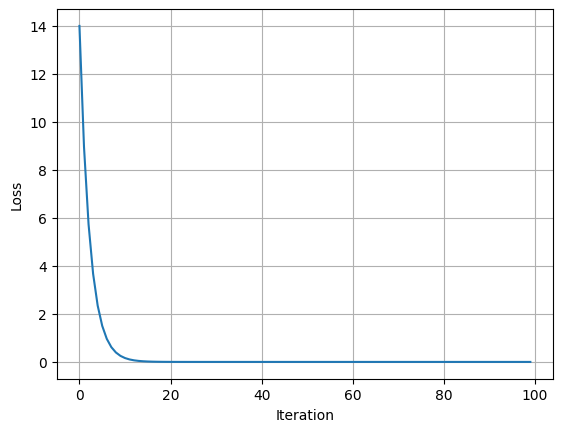

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid()
plt.show()
plt.savefig(os.path.join('results', 'torch_optimization.%s' % fig_format), format=fig_format)

## 4.3 Descida do Gradiente em NumPy

A função auxiliar ``gradient_function()`` já foi fornecida como exemplo, e portanto não precisa ser implementada. Você precisa apenas implementar a função ``gradient_descent_numpy()``, que implementa a Descida do Gradiente usando NumPy puro. **Não** use PyTorch para calcular o gradiente, use a função `gradient_function(theta)`. Neste caso, você deve realizar o cálculo da iteração da Descida do Gradiente manualmente:
$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \alpha \left. \frac{\partial J}{\partial \boldsymbol{\theta}} \right|_{\boldsymbol{\theta}=\boldsymbol{\theta}_k}
$$

In [ ]:
def gradient_function(theta: np.array) -> np.array:
    """
    Samples the gradient of the linear regression cost function.

    :param theta: parameter point.
    :type theta: numpy.array.
    :return: gradient at theta.
    :rtype: float.
    """
    m = len(t)
    return np.array([(1 / m) * sum(theta[0] + theta[1] * t - v),
                    (1 / m) * sum((theta[0] + theta[1] * t - v) * t)])

In [ ]:
from typing import Callable, Tuple

def gradient_descent_numpy(cost_function: Callable, gradient_function: Callable,
                           theta0: np.array, alpha: float, epsilon: float,
                           max_iterations: int) -> Tuple[np.array, list]:
    """
    Executes the Gradient Descent (GD) algorithm to minimize (optimize) a cost function.
    Implementation using pure NumPy.

    :param cost_function: function to be minimized.
    :type cost_function: function.
    :param gradient_function: gradient of the cost function.
    :type gradient_function: function.
    :param theta0: initial guess.
    :type theta0: numpy.array.
    :param alpha: learning rate.
    :type alpha: float.
    :param epsilon: used to stop the optimization if the current cost is less than epsilon.
    :type epsilon: float.
    :param max_iterations: maximum number of iterations.
    :type max_iterations: int.
    :return theta: local minimum.
    :rtype theta: numpy.array.
    :return history: history of points visited by the algorithm.
    :rtype history: list of numpy.array.
    """
    theta = theta0
    history = [theta0]
    # Todo: Implement Gradient Descent using pure NumPy
    num_iterations = 0;
    while num_iterations < max_iterations and cost_function(theta) > epsilon:
      theta = theta - alpha*gradient_function(theta)
      history.append(theta)
      num_iterations +=1

    return theta, history

### Teste da Implementação Descida do Gradiente usando NumPy

Gradient Descent solution:  [ 0.43337067 -0.10101846]


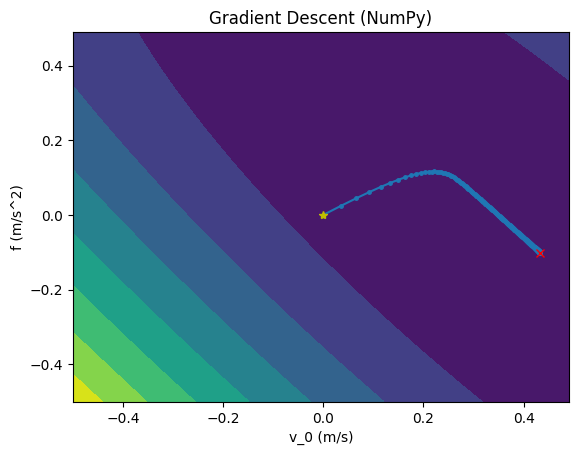

In [ ]:
import os

# Setting random seed for reproducibility
np.random.seed(42)

t, v = load_data() # Load the data

# Solving the problem using the Gradient Descent algorithm implemented with NumPy
theta, history = gradient_descent_numpy(cost_function, gradient_function, np.array([0.0, 0.0]), 0.1, 1.0e-10, 1000)
print('Gradient Descent solution: ', theta)
plt.figure()
plot_optimization(history)
plt.title('Gradient Descent (NumPy)')
plt.savefig(os.path.join('results', 'gradient_descent_numpy.%s' % fig_format), format=fig_format)

## 4.4 Descida do Gradiente em PyTorch

Você precisa apenas implementar a função ``gradient_descent_torch()``, que implementa a Descida do Gradiente usando PyTorch. Aqui, você deve explicitamente as funcionalidades apresentadas anteriormente da PyTorch, incluindo o método `backward()` para cálculo automático de gradiente, para realizar a Descida do Gradiente. Recomenda-se usar o código de otimização usando PyTorch apresentado anteriormente como *template*.

Lembre que a implementação da Descida de Gradiente deve ser genérica. **Não** assumir que o problema é uma regressão linear dentro de `gradient_descent_torch()`.

In [ ]:
def cost_function_torch(theta: torch.tensor) -> torch.tensor:
    """
    Computes the cost function for the linear regression at the current theta (PyTorch implementation).
    In this case, the cost is computed as a PyTorch's tensor, so we can
    compute the gradient using backward().

    :param theta: parameter point.
    :type theta: torch.tensor.
    :return: cost value at theta.
    :rtype: torch.tensor.
    """
    # Implement the cost function for linear regression using PyTorch operations
    cost = (theta[0] + theta[1]*t - v).pow(2)
    return cost.mean()

def gradient_descent_torch(cost_function: Callable, theta0: torch.tensor, alpha: float, epsilon: float,max_iterations: int) -> Tuple[torch.tensor, list]:
    """
    Executes the Gradient Descent (GD) algorithm to minimize (optimize) a cost function.
    Implementation using PyTorch.

    :param cost_function: function to be minimized.
    :type cost_function: function.
    :param gradient_function: gradient of the cost function.
    :type gradient_function: function.
    :param theta0: initial guess.
    :type theta0: torch.tensor.
    :param alpha: learning rate.
    :type alpha: float.
    :param epsilon: used to stop the optimization if the current cost is less than epsilon.
    :type epsilon: float.
    :param max_iterations: maximum number of iterations.
    :type max_iterations: int.
    :return theta: local minimum.
    :rtype theta: torch.tensor.
    :return history: history of points visited by the algorithm.
    :rtype history: list of torch.tensor.
    """
    theta = theta0
    history = [theta0.detach().clone()]
    optimizer = torch.optim.SGD([theta], lr=alpha) # Stochastic Gradient Descent optimizer
    # Todo: Implement Gradient Descent using PyTorch

    num_iterations = 0
    while num_iterations < max_iterations and cost_function(theta).detach().item() > epsilon:
      optimizer.zero_grad()
      loss = cost_function(theta)
      loss.backward()
      optimizer.step()
      history.append(theta.detach().clone().numpy())
      #history.append([num_iterations,loss.detach().item()])
      num_iterations +=1

    return theta, history

Gradient Descent solution:  tensor([ 0.4334, -0.1010], requires_grad=True)


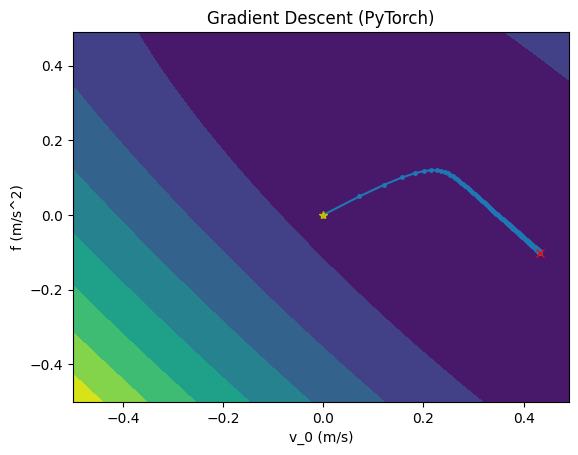

In [ ]:
import os

# Setting random seed for reproducibility
np.random.seed(42)

t, v = load_data() # Load the data
t = torch.tensor(t, dtype=torch.float32)
v = torch.tensor(v, dtype=torch.float32)

# Solving the problem using the Gradient Descent algorithm implemented with PyTorch
theta0 = torch.tensor([0.0, 0.0], requires_grad=True)
theta, history = gradient_descent_torch(cost_function_torch, theta0, 0.1, 1.0e-10, 1000)
print('Gradient Descent solution: ', theta)
plt.figure()
plot_optimization(history)
plt.title('Gradient Descent (PyTorch)')
plt.savefig(os.path.join('results', 'gradient_descent_torch.%s' % fig_format), format=fig_format)

## 4.5 Comparação dos Métodos

/tmp/ipykernel_6889/2928864671.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  v_torch = theta_torch[0] + theta_torch[1] * torch.tensor(t)


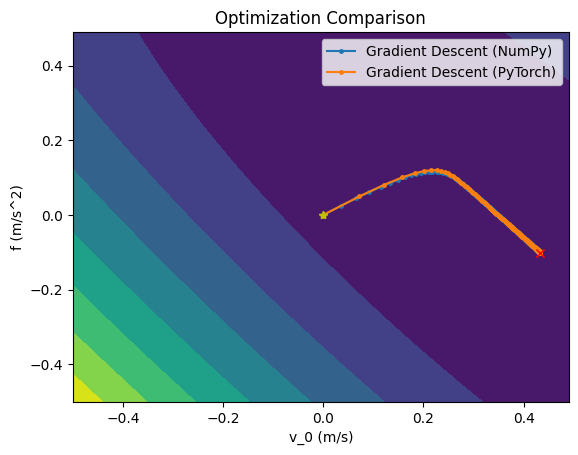

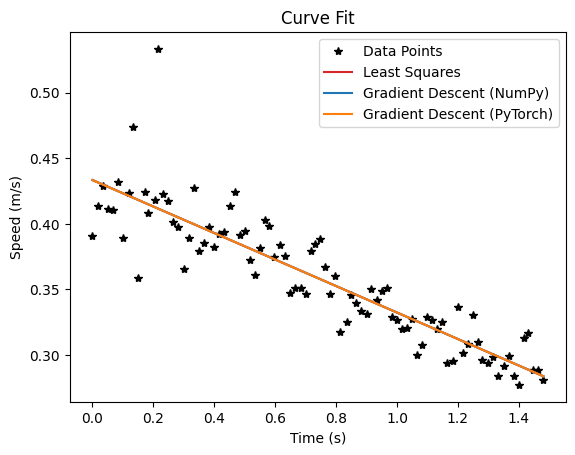

In [ ]:
import random
from math import pi, cos, sin
from least_squares import least_squares

# Setting random seed for reproducibility
random.seed(42)

t, v = load_data()

# Solving the problem using Least Squares in order to obtain ground truth
theta_ls = least_squares([lambda x: 1.0, lambda x: x], t, v)

# Solving the problem using each algorithm and plotting the optimization history of each algorithm
theta_np, history_np = gradient_descent_numpy(cost_function, gradient_function, np.array([0.0, 0.0]), 0.1, 1.0e-10, 1000)
t = torch.tensor(t, dtype=torch.float32)
v = torch.tensor(v, dtype=torch.float32)
theta_torch, history_torch = gradient_descent_torch(cost_function_torch, torch.tensor([0.0, 0.0], requires_grad=True), 0.1, 1.0e-10, 1000)
theta_torch = theta_torch.detach()

# Plotting the optimization histories in a single plot for comparison
plt.figure()
handle_np = plot_optimization(history_np)
handle_torch = plot_optimization(history_torch)
plt.legend([handle_np, handle_torch], ['Gradient Descent (NumPy)', 'Gradient Descent (PyTorch)'])
plt.title('Optimization Comparison')
plt.savefig(os.path.join('results', 'optimization_comparison.%s' % fig_format), format=fig_format)

# Plotting the curve fit
plt.figure()
plt.plot(t, v, '*k')
v_ls = theta_ls[0] + theta_ls[1] * t
v_np = theta_np[0] + theta_np[1] * t
v_torch = theta_torch[0] + theta_torch[1] * torch.tensor(t)
plt.plot(t, v_ls, 'tab:red')
plt.plot(t, v_np, 'tab:blue')
plt.plot(t, v_torch, 'tab:orange')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.legend(['Data Points', 'Least Squares', 'Gradient Descent (NumPy)', 'Gradient Descent (PyTorch)'])
plt.title('Curve Fit')
plt.savefig(os.path.join('results', 'fit_comparison.%s' % fig_format), format=fig_format)
plt.show()

In [ ]:
import pandas as pd

# create comparison table
table = pd.DataFrame(data = np.vstack((theta_ls, theta_np, theta_torch)),
                     columns = ['v0', 'f'],
                     index = ['Least-Squares Method', 'Gradient Descent (NumPy)', 'Gradient Descent (PyTorch)'],
                    )
print('Linear regression parameters obtained by the optimization methods')
display(table)

Linear regression parameters obtained by the optimization methods


,v0,f
Least-Squares Method,0.433373,-0.101021
Gradient Descent (NumPy),0.433371,-0.101018
Gradient Descent (PyTorch),0.433372,-0.101021


**Inclua a tabela acima no seu relatório!**

# 5. Entrega

A entrega consiste do notebook no formato .ipynb e de um relatório, submetida através do Google Classroom. Evite modificações nos arquivos do código base além do que é solicitado. A princípio, não há limitação de número de páginas para o relatório, mas pede-se que seja sucinto. O relatório deve conter:

- Breve descrição em alto nível da sua implementação.
- Figuras que comprovem o funcionamento do seu código (incluir todas as figuras salvas automaticamente).
- Breve análise dos resultados.

Por limitações do Google Classroom (e por motivo de facilitar a automatização da correção), entregue seu laboratório com todos os arquivos num único arquivo **.zip** (**não** utilize outras tecnologias de compactação de arquivos) com o seguinte padrão de nome: **“<login_email_google_education>_labX.zip”**. Por exemplo, no meu caso, meu login Google Education é **marcos.maximo**, logo eu entregaria o lab 3 como **“marcos.maximo_lab1.zip”**. **Não** crie subpastas para os arquivos da sua entrega, **deixe todos os arquivos na “raiz” do .zip**. Os relatórios devem ser entregues em formato **.pdf**.


# 6. Dicas

- Para fazer o download do notebook no Colab, vá em ``File > Download >  Download .ipynb``

- Para fazer o download das figuras e usá-las no relatório, use os seguintes comandos:
```python
from google.colab import files
import os
os.system('zip -r lab1_results.zip results')
files.download("lab1_results.zip")
```